In [1]:
# ==============================================================================
# CÉLULA 1B: SETUP E CONFIGURAÇÕES INICIAIS
# ==============================================================================
import sys
import os
import logging

# 1. Configuração do Diretório (Garante conexão com o Drive se rodar no Colab)
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    caminho_projeto = '/content/drive/MyDrive/1) PESQUISA/ESALQ Data Science/tcc/tema_classificacao_queda_arvore/git/tcc_risco_queda_v-pub'
    sys.path.append(caminho_projeto)
    os.chdir(caminho_projeto)
    print("✅ Diretório Colab configurado:", os.getcwd())
except ImportError:
    # Se estiver rodando localmente (não no Colab)
    print("✅ Rodando em ambiente local:", os.getcwd())

Mounted at /content/drive
✅ Diretório Colab configurado: /content/drive/MyDrive/1) PESQUISA/ESALQ Data Science/tcc/tema_classificacao_queda_arvore/git/tcc_risco_queda_v-pub


In [2]:
# ==============================================================================
# CÉLULA 1: SETUP E CONFIGURAÇÕES INICIAIS
# ==============================================================================
import sys
import os
import logging
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, recall_score, precision_score, accuracy_score
from scipy.stats import ks_2samp
from statsmodels.stats.outliers_influence import variance_inflation_factor
from IPython.display import display
from sklearn.model_selection import cross_val_predict

# Importando os seus módulos personalizados da pasta src
from src.optimization import otimizar_threshold_financeiro
from src.visualization import plotar_tradeoff_financeiro
from src.evaluation import calcular_metricas_limiar, extrair_matriz_quadrantes

In [ ]:
# CELULA 1C: 2. Configurações Globais de Visualização
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['text.color'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'

# Garante que a pasta de resultados existe
os.makedirs('results/figures', exist_ok=True)
os.makedirs('results/tables', exist_ok=True)

In [3]:
# Defina o nome do cenário atual aqui
nome_cenario = "cenario_abrangente"
if 'data_hora_base' not in globals():
    data_hora_base = datetime.now().strftime("_%Y%m%d-%H%M")
sufixo_data = f"{data_hora_base}_{nome_cenario}"

# Opcional: Melhora a qualidade da renderização no Colab
try:
    %config InlineBackend.figure_format = 'retina'
except:
    pass

In [35]:
# ==============================================================================
# CÉLULA 2: CARREGAMENTO DO MASTER DATASET E DEFINIÇÃO DO ESCOPO
# ==============================================================================

# 1. Carregamento do Novo Master Dataset (GPKG)
file_path = "data/processed/dataset_MASTER.parquet"
print("📂 Carregando dataset master dedupilado...")
df_parquet = pd.read_parquet(file_path)

# Convertendo binário WKB para geometrias ativas
df_parquet['geometry'] = gpd.GeoSeries.from_wkb(df_parquet['geometry'])

# 2. Transformar agora com sucesso em GeoDataFrame
df_full = gpd.GeoDataFrame(df_parquet, geometry='geometry', crs="EPSG:31983")

print(f"🌍 Base Total Carregada: {len(df_full)} segmentos viários.")

# 2. Base para Modelagem (Cópia para preservar o original)
df_modelagem = df_full.copy()

# 3. Definição do Alvo (Target) e Remoção de Vazamento (Leakage)
target = 'target_queda_bool'

colunas_ignorar = [
    'cvc_nomelg', 'cvc_tplogr', 'cvc_classe',  # Nomes de ruas / IDs
    'target_historico_quedas',                 # Contagem exata de quedas (Vazamento)
    'geometry'                                 # Geometria direta não vai para o modelo
]

# Separação X e y
X = df_modelagem.drop(columns=colunas_ignorar + [target])
y = df_modelagem[target]

# 4. Identificação Automática de Dtypes
features_numericas = X.select_dtypes(include=['number']).columns.tolist()
features_categoricas = X.select_dtypes(include=['category', 'object']).columns.tolist()

print(f"📊 Modelagem iniciada com {len(df_modelagem)} amostras.")
print(f"🔹 Features Numéricas ({len(features_numericas)}): {features_numericas}")
print(f"🔹 Features Categóricas ({len(features_categoricas)}): {features_categoricas}")

# 5. Separação Treino/Teste (80/20) com Estratificação (ANTES DO PRE-PROCESSAMENTO)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"✅ Split concluído com sucesso. Treino: {len(X_train)} | Teste: {len(X_test)}")

📂 Carregando dataset master dedupilado...
🌍 Base Total Carregada: 110956 segmentos viários.
📊 Modelagem iniciada com 110956 amostras.
🔹 Features Numéricas (17): ['via_extensao_km', 'via_azimute_graus', 'via_calcada_largura_min', 'via_calcada_declinacao_max', 'via_arvores_contagem', 'via_icc_confinamento_idx', 'stat_aiv_arvores_isoladas', 'stat_dva_vizinhanca_dist_med', 'stat_dva_vizinhanca_dist_std', 'stat_idag_densidade_grav_med', 'stat_idag_densidade_grav_std', 'socio_densidade_demog_hab_ha', 'infra_escolas_contagem', 'infra_semaforos_contagem', 'infra_iluminacao_contagem', 'infra_onibus_pontos_contagem', 'geo_solo_mole_area_m2']
🔹 Features Categóricas (6): ['socio_zona_fiscal_cat', 'socio_vulnerabilidade_idx', 'infra_uso_solo_cat', 'geo_declividade_terreno_cat', 'geo_relevo_tipo_cat', 'geo_litologia_tipo_cat']
✅ Split concluído com sucesso. Treino: 88764 | Teste: 22192


In [ ]:
# ==============================================================================
# CÉLULA 3: CONSTRUÇÃO DO PRÉ-PROCESSADOR (PIPELINE)
# ==============================================================================
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

print("⚙️ Construindo Pré-processador universal...")

# Pipeline Numérico: Imputação + Escalonamento
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline Categórico: Imputação + OneHot Encoding
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='DESCONHECIDO')),
    ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

# Processador que será encaixado nos modelos
pre_processador = ColumnTransformer([
    ('num', num_pipe, features_numericas),
    ('cat', cat_pipe, features_categoricas)
])

print("✅ Pré-processador pronto para ser acoplado aos modelos.")

⚙️ Construindo Pré-processador universal...
✅ Pré-processador pronto para ser acoplado aos modelos.


In [ ]:
# ==============================================================================
# CÉLULA 4: AUDITORIA ESTATÍSTICA E COLINEARIDADE (VIF)
# ==============================================================================
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

print("🔬 Iniciando Análise de Multicolinearidade (VIF) nos dados de Treino...")

# 1. Aplicamos o pipeline numérico (Imputação + Scaler) APENAS no X_train para evitar vazamento
X_train_num_clean = num_pipe.fit_transform(X_train[features_numericas])
X_train_num_df = pd.DataFrame(X_train_num_clean, columns=features_numericas, index=X_train.index)

# 2. Adicionamos a constante exigida pelo statsmodels
X_vif_const = add_constant(X_train_num_df)

# 3. Cálculo do VIF
vif_data = pd.DataFrame({
    "Variável": X_vif_const.columns,
    "VIF": [variance_inflation_factor(X_vif_const.values, i) for i in range(X_vif_const.shape[1])]
})

vif_data = vif_data[vif_data['Variável'] != 'const'].sort_values('VIF', ascending=True)

# 4. Exibição e Exportação (Apenas CSV)
print("\n📊 Resultado do VIF (Atenção para valores > 5):")
display(vif_data.tail(10))

nome_arquivo_csv = f'results/tables/02_tabela_vif_{sufixo_data}.csv'
vif_data.round(4).to_csv(nome_arquivo_csv, sep=';', decimal=',', index=False)
print(f"✅ Tabela VIF exportada: {nome_arquivo_csv}")

🔬 Iniciando Análise de Multicolinearidade (VIF) nos dados de Treino...

📊 Resultado do VIF (Atenção para valores > 5):


,Variável,VIF
4,via_calcada_declinacao_max,1.162395
6,via_icc_confinamento_idx,1.291159
9,stat_dva_vizinhanca_dist_std,1.293397
8,stat_dva_vizinhanca_dist_med,1.309401
7,stat_aiv_arvores_isoladas,1.329864
3,via_calcada_largura_min,1.367877
1,via_extensao_km,1.621356
5,via_arvores_contagem,1.732499
10,stat_idag_densidade_grav_med,2.578112
11,stat_idag_densidade_grav_std,2.619924


✅ Tabela VIF exportada: results/tables/02_tabela_vif__20260331-1023_cenario_completo_triade_v1.csv


In [ ]:
# ==============================================================================
# CÉLULA 5: TREINAMENTO DOS BASELINES E REGRESSÕES LINEARES
# ==============================================================================
print("🚀 Iniciando o Treinamento dos Baselines e Modelos Lineares...")

# 1. BASELINE 1: ALEATÓRIO (Chute Uniforme 50/50)
pipe_dummy_random = DummyClassifier(strategy='uniform', random_state=42)
pipe_dummy_random.fit(X_train, y_train)
print("✅ Baseline 1 (Aleatório) treinado.")

# 2. BASELINE 2: MAIORIA (Prevê sempre a classe dominante)
pipe_dummy_majority = DummyClassifier(strategy='most_frequent')
pipe_dummy_majority.fit(X_train, y_train)
print("✅ Baseline 2 (Maioria) treinado.")

# 3. BASELINE 3: REGRESSÃO LOGÍSTICA SIMPLES (Sem Penalidade)
pipe_logistica = Pipeline([
    ('pre', pre_processador),
    ('modelo', LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42))
])
pipe_logistica.fit(X_train, y_train)
print("✅ Baseline 3 (Logística Padrão) treinado.")

# 4. MODELO LINEAR PRINCIPAL: LASSO (Com Penalidade L1)
pipe_lasso = Pipeline([
    ('pre', pre_processador),
    ('modelo', LogisticRegression(
        penalty='l1', solver='liblinear', class_weight='balanced',
        random_state=42, max_iter=2000, C=1.0
    ))
])
pipe_lasso.fit(X_train, y_train)
print("✅ Modelo Principal Linear (LASSO) treinado!")

# ==============================================================================
# EXTRAÇÃO DE COEFICIENTES DO LASSO (FATORES DE RISCO E PROTEÇÃO)
# ==============================================================================
nomes_features_finais = pipe_lasso.named_steps['pre'].get_feature_names_out()
nomes_limpos = [nome.replace('num__', '').replace('cat__', '') for nome in nomes_features_finais]

pesos_lasso = pipe_lasso.named_steps['modelo'].coef_[0]

df_coeficientes = pd.DataFrame({'Variavel': nomes_limpos, 'Peso_Lasso': pesos_lasso})
df_coeficientes = df_coeficientes.sort_values(by='Peso_Lasso', ascending=False)

sobreviveram = df_coeficientes[df_coeficientes['Peso_Lasso'] != 0].shape[0]
zeradas = df_coeficientes[df_coeficientes['Peso_Lasso'] == 0].shape[0]

print(f"\n🔍 RESUMO DA REGRESSÃO LASSO: {sobreviveram} variáveis mantidas, {zeradas} zeradas.")

# Exportação estrita para CSV
df_coeficientes.to_csv(f'results/tables/04_pesos_lasso_{sufixo_data}.csv', sep=';', decimal=',', index=False)

🚀 Iniciando o Treinamento dos Baselines e Modelos Lineares...
✅ Baseline 1 (Aleatório) treinado.
✅ Baseline 2 (Maioria) treinado.
✅ Baseline 3 (Logística Padrão) treinado.
✅ Modelo Principal Linear (LASSO) treinado!

🔍 RESUMO DA REGRESSÃO LASSO: 65 variáveis mantidas, 3 zeradas.


In [ ]:
# ==============================================================================
# CÉLULA 6: OTIMIZAÇÃO DO XGBOOST (K-FOLD ESPACIAL)
# ==============================================================================
from sklearn.model_selection import RandomizedSearchCV, GroupKFold

print("⚙️ Iniciando configuração do XGBoost...")

# 1. Agrupamento Espacial e Pesos
groups_train = df_modelagem.loc[X_train.index, 'socio_zona_fiscal_cat']
peso_positivo = (len(y_train) - y_train.sum()) / y_train.sum() if y_train.sum() > 0 else 1

pipe_xgb_base = Pipeline([
    ('pre', pre_processador),
    ('modelo', XGBClassifier(random_state=42, scale_pos_weight=peso_positivo))
])

# 2. Lógica de Busca e Cache (Estritamente CSV)
caminho_params_csv = f'results/tables/05_xgb_best_params_{nome_cenario}.csv'

if os.path.exists(caminho_params_csv):
    print(f"📥 Cache encontrado! Carregando parâmetros de: {caminho_params_csv}")
    df_params = pd.read_csv(caminho_params_csv, sep=';')
    best_params = df_params.iloc[0].to_dict()

    # Garantindo que parâmetros de contagem de árvores/profundidade voltem como Inteiros
    for col in ['modelo__n_estimators', 'modelo__max_depth']:
        if col in best_params:
            best_params[col] = int(best_params[col])

else:
    print("⏳ Iniciando Validação Cruzada Espacial (RandomizedSearchCV)...")
    param_dist = {
        'modelo__n_estimators': [100, 200, 300],
        'modelo__max_depth': [3, 4, 5, 7],
        'modelo__learning_rate': [0.01, 0.05, 0.1],
        'modelo__subsample': [0.7, 0.8, 0.9],
        'modelo__reg_alpha': [0, 0.1, 1, 10],
        'modelo__reg_lambda': [1, 5, 10, 20]
    }

    search_xgb = RandomizedSearchCV(
        pipe_xgb_base, param_distributions=param_dist, n_iter=10,
        scoring='recall', cv=GroupKFold(n_splits=5), verbose=1,
        random_state=42, n_jobs=-1
    )

    search_xgb.fit(X_train, y_train, groups=groups_train)
    best_params = search_xgb.best_params_

    # Exportação estrita para CSV
    pd.DataFrame([best_params]).to_csv(caminho_params_csv, sep=';', index=False)
    print(f"💾 Parâmetros otimizados salvos em CSV: {caminho_params_csv}")

# 3. Treinamento Final do XGBoost
print("\n🌳 Treinando XGBoost Final com os melhores parâmetros...")
pipe_xgb_final = pipe_xgb_base.set_params(**best_params)
pipe_xgb_final.fit(X_train, y_train)

print("✅ XGBoost treinado e pronto para predições!")

⚙️ Iniciando configuração do XGBoost...
📥 Cache encontrado! Carregando parâmetros de: results/tables/05_xgb_best_params_cenario_completo_triade_v1.csv

🌳 Treinando XGBoost Final com os melhores parâmetros...
✅ XGBoost treinado e pronto para predições!


🎲 Gerando probabilidades para a base de Teste (20%)...


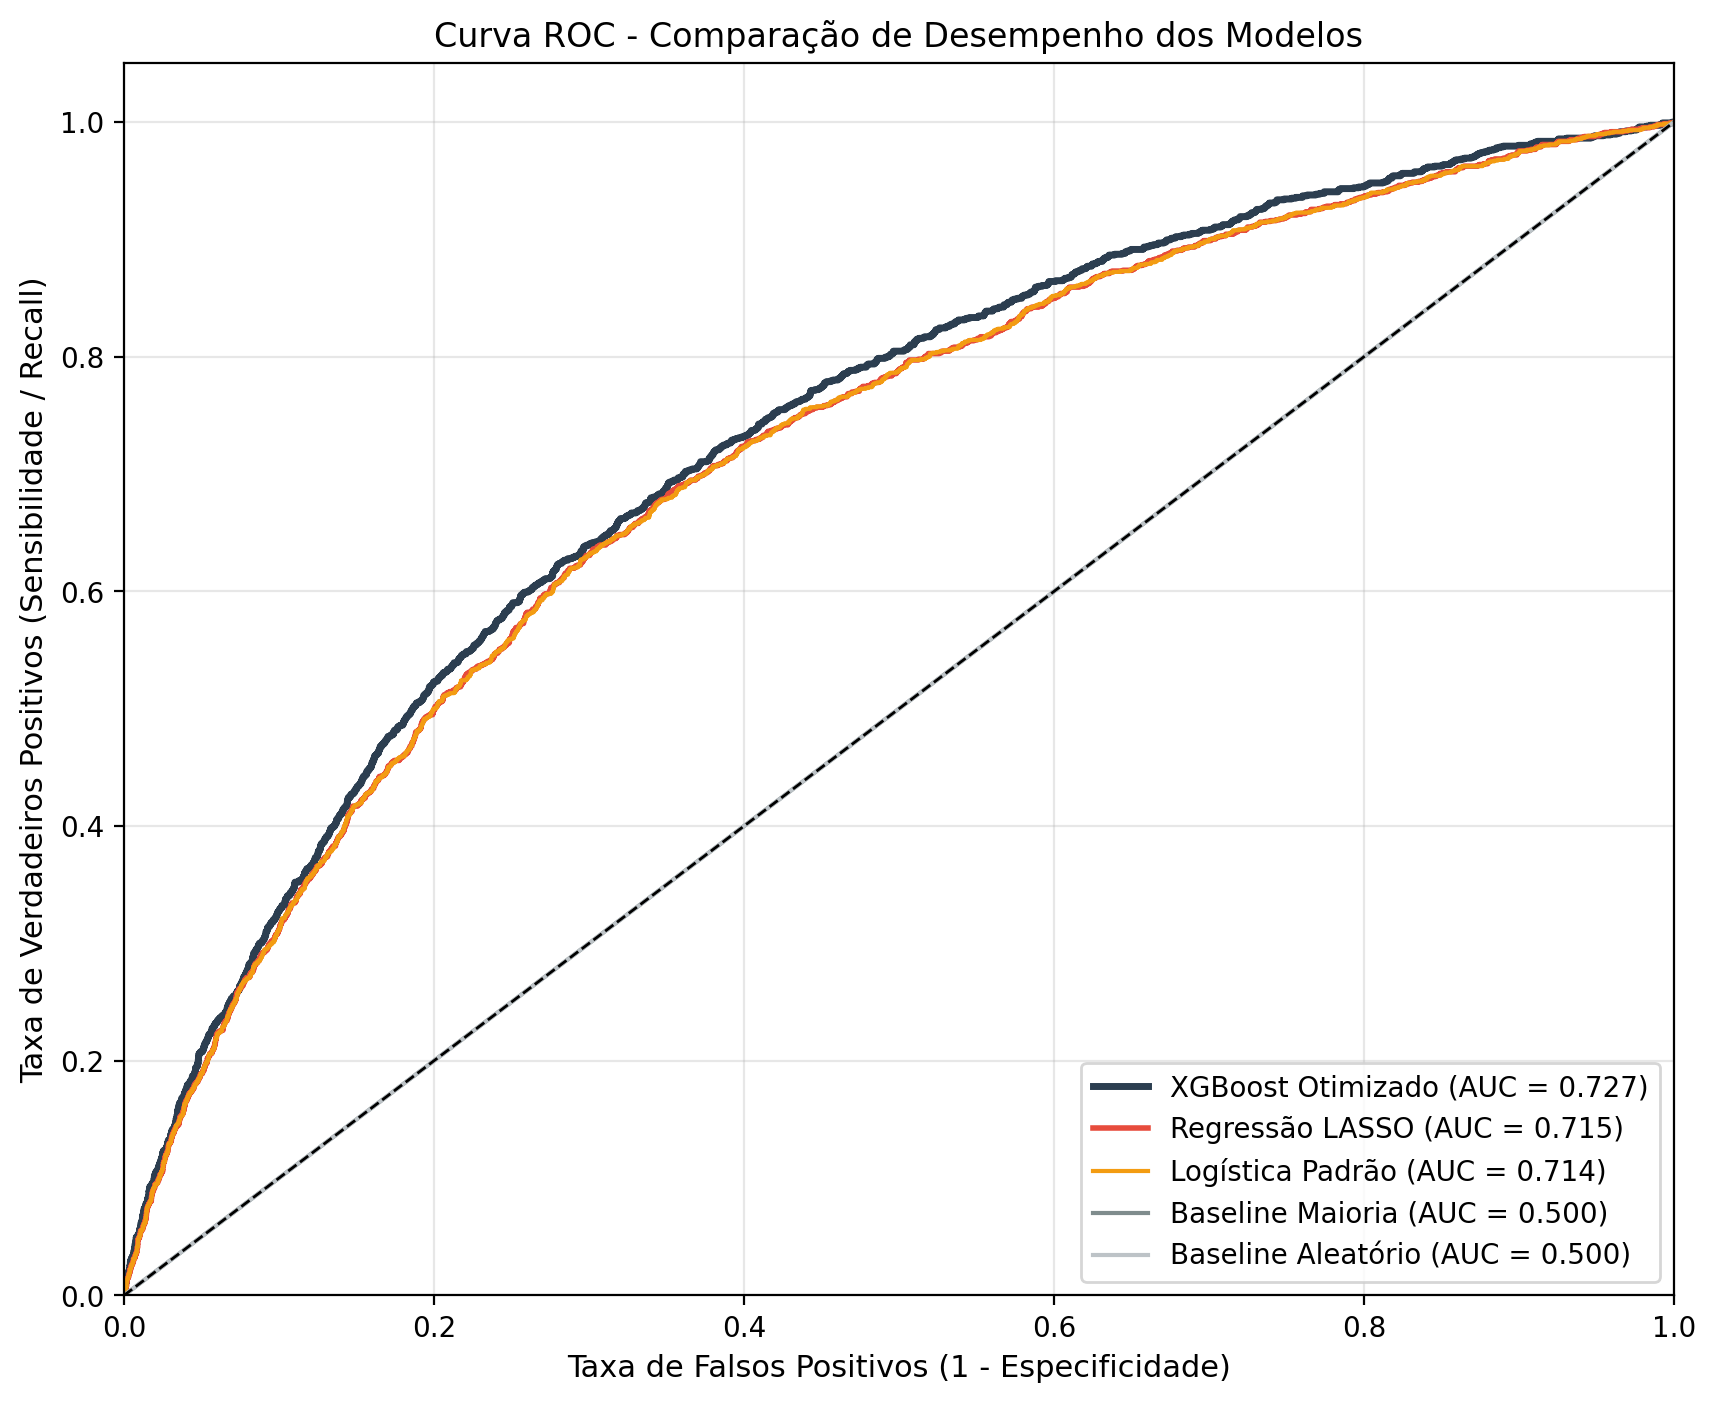

✅ Curva ROC exportada em PNG e Predições salvas em CSV.


In [ ]:
# ==============================================================================
# CÉLULA 7: PREDIÇÕES NA BASE DE TESTE E CURVA ROC
# ==============================================================================
from sklearn.metrics import roc_curve, auc, roc_auc_score

print("🎲 Gerando probabilidades para a base de Teste (20%)...")

# 1. Geração das Probabilidades
df_test_results = pd.DataFrame({'target_real': y_test})

# Extraindo apenas a probabilidade da classe 1 (Queda)
df_test_results['prob_aleatorio'] = pipe_dummy_random.predict_proba(X_test)[:, 1]
df_test_results['prob_maioria'] = pipe_dummy_majority.predict_proba(X_test)[:, 1]
df_test_results['prob_logistica'] = pipe_logistica.predict_proba(X_test)[:, 1]
df_test_results['prob_lasso'] = pipe_lasso.predict_proba(X_test)[:, 1]
df_test_results['prob_xgb'] = pipe_xgb_final.predict_proba(X_test)[:, 1]

# Exporta matriz de resultados brutos
df_test_results.to_csv(f'results/tables/06_predicoes_teste_{sufixo_data}.csv', index=False, sep=';', decimal=',')

# 2. Plotagem da Curva ROC (Comparação de Modelos)
plt.figure(figsize=(10, 8))

dicionario_modelos = {
    'XGBoost Otimizado': ('prob_xgb', '#2c3e50', 2.5),
    'Regressão LASSO': ('prob_lasso', '#e74c3c', 2.0),
    'Logística Padrão': ('prob_logistica', '#f39c12', 1.5),
    'Baseline Maioria': ('prob_maioria', '#7f8c8d', 1.5),
    'Baseline Aleatório': ('prob_aleatorio', '#bdc3c7', 1.5)
}

for nome, (coluna, cor, lw) in dicionario_modelos.items():
    fpr, tpr, _ = roc_curve(y_test, df_test_results[coluna])
    auc_score = roc_auc_score(y_test, df_test_results[coluna])
    plt.plot(fpr, tpr, color=cor, lw=lw, label=f'{nome} (AUC = {auc_score:.3f})')

# Linha de chance (50%)
plt.plot([0, 1], [0, 1], color='black', lw=1, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (1 - Especificidade)')
plt.ylabel('Taxa de Verdadeiros Positivos (Sensibilidade / Recall)')
plt.title('Curva ROC - Comparação de Desempenho dos Modelos')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

# Exportação do Gráfico
caminho_roc = f'results/figures/01_curva_roc_modelos_{sufixo_data}.png'
plt.savefig(caminho_roc, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Curva ROC exportada em PNG e Predições salvas em CSV.")

In [ ]:
# ==============================================================================
# CÉLULA 8: SIMULAÇÃO DE CUSTO OPERACIONAL (TRADE-OFF TABULAR)
# ==============================================================================
import pandas as pd
from sklearn.metrics import confusion_matrix, recall_score, precision_score
import os

print("🚦 Simulando cenários operacionais de ponto de corte (Threshold)...")

limiares_teste = [0.50, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20, 0.15]
resultados_simulacao = []

for limiar in limiares_teste:
    # Usando as probabilidades do XGBoost geradas na Célula 7
    y_pred_sim = (df_test_results['prob_xgb'] >= limiar).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_sim).ravel()

    recall = recall_score(y_test, y_pred_sim)
    precisao = precision_score(y_test, y_pred_sim, zero_division=0)

    resultados_simulacao.append({
        'Threshold': limiar,
        'Recall (Segurança) %': f"{recall*100:.1f}%",
        'Precisão (Assertividade) %': f"{precisao*100:.1f}%",
        'Quedas Detectadas (VP)': tp,
        'Riscos Omitidos (FN)': fn,
        'Alarmes Falsos (FP)': fp,
        'Vistorias Totais (Carga)': tp + fp
    })

df_simulacao = pd.DataFrame(resultados_simulacao).set_index('Threshold')
display(df_simulacao)

caminho_simulacao = f'results/tables/07_simulacao_custo_operacional_{sufixo_data}.csv'
df_simulacao.to_csv(caminho_simulacao, sep=';', decimal=',')
print(f"\n✅ Tabela de simulação exportada para: {caminho_simulacao}")

🚦 Simulando cenários operacionais de ponto de corte (Threshold)...


,Recall (Segurança) %,Precisão (Assertividade) %,Quedas Detectadas (VP),Riscos Omitidos (FN),Alarmes Falsos (FP),Vistorias Totais (Carga)
Threshold,,,,,,
0.50,65.2%,12.8%,955,510,6512,7467
0.45,74.9%,11.2%,1098,367,8671,9769
0.40,82.8%,9.9%,1213,252,11082,12295
0.35,89.0%,8.8%,1304,161,13436,14740
0.30,93.5%,8.0%,1370,95,15649,17019
0.25,96.4%,7.4%,1412,53,17695,19107
0.20,98.6%,7.0%,1444,21,19289,20733
0.15,99.7%,6.6%,1461,4,20531,21992



✅ Tabela de simulação exportada para: results/tables/07_simulacao_custo_operacional__20260331-1023_cenario_completo_triade_v1.csv


🔍 Otimizando o ponto de corte com base nos custos da PMSP...
🎯 Threshold Operacional Ideal: 0.46


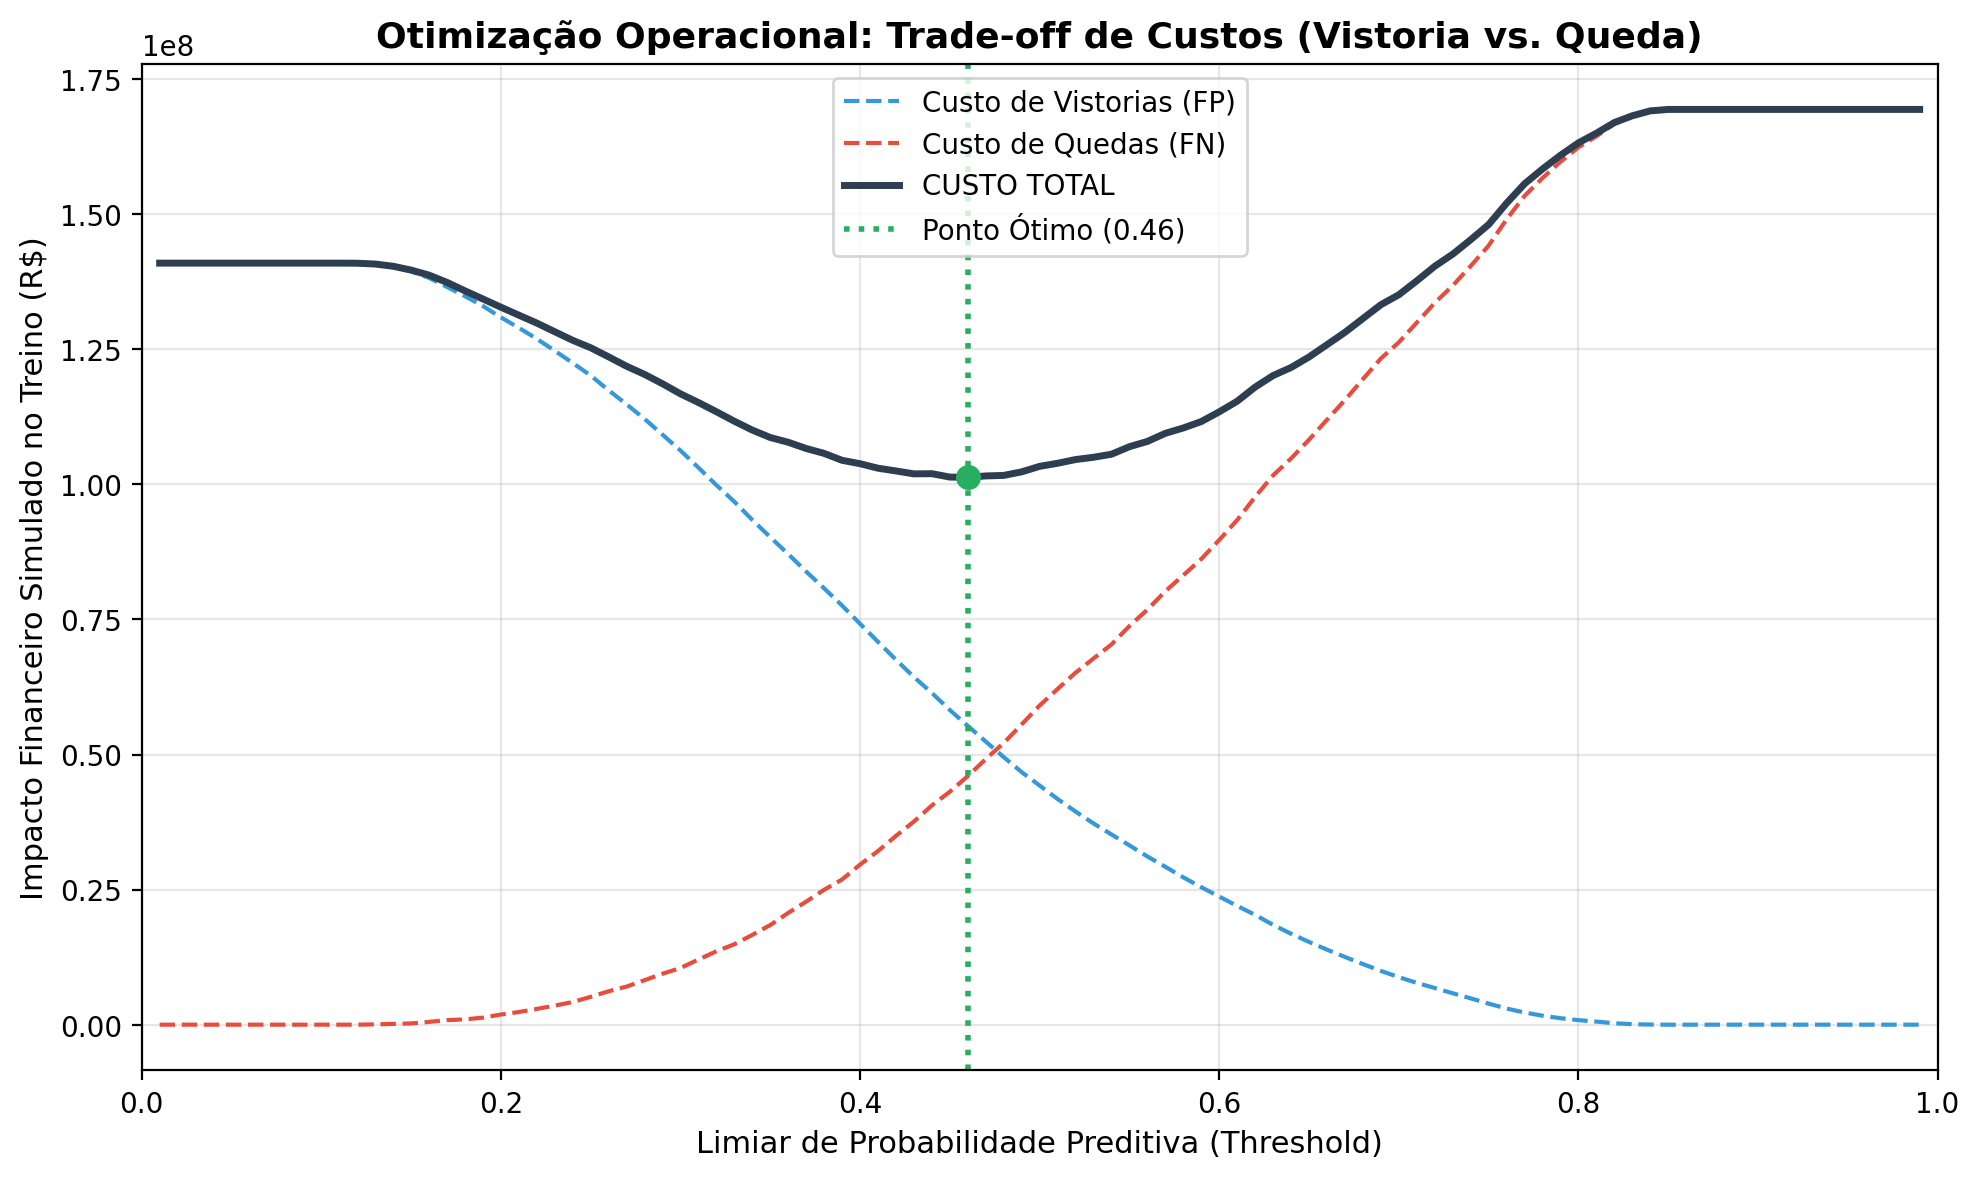

In [ ]:
# ==============================================================================
# CÉLULA 8: OTIMIZAÇÃO DO THRESHOLD (TRADE-OFF FINANCEIRO E OPERACIONAL)
# ==============================================================================
print("🔍 Otimizando o ponto de corte com base nos custos da PMSP...")

# 1. Geração Out-Of-Fold no Treino (Rigor Científico contra Leakage)
y_prob_train_oof = cross_val_predict(
    pipe_xgb_final, X_train, y_train, cv=5, method='predict_proba', n_jobs=-1
)[:, 1]

# 2. Chama a função de negócio do src/optimization.py
# (Premissa: Vistoria = R$ 1.700 | Queda = 17x o valor da vistoria)
resultado_otimizacao = otimizar_threshold_financeiro(
    y_train,
    y_prob_train_oof,
    custo_fp=1700,
    multiplicador_fn=17
)

threshold_otimo = resultado_otimizacao['threshold_otimo']
menor_custo = resultado_otimizacao['menor_custo_total']
print(f"🎯 Threshold Operacional Ideal: {threshold_otimo:.2f}")

# 3. Plota e exporta o gráfico chamando o src/visualization.py
caminho_figura_tradeoff = f'results/figures/02_simulacao_custo_threshold_{sufixo_data}.png'

plotar_tradeoff_financeiro(
    historico_custos=resultado_otimizacao['historico'],
    threshold_otimo=threshold_otimo,
    menor_custo=menor_custo,
    caminho_exportacao=caminho_figura_tradeoff
)

In [ ]:
# ==============================================================================
# CÉLULA 9: AVALIAÇÃO GLOBAL DE DESEMPENHO (MÉTRICAS E MATRIZES)
# ==============================================================================
print("📊 Consolidando Métricas Avançadas e Matrizes de Confusão...")

# 1. Aplicando a função do src/evaluation.py para as Métricas Globais
tabela_metricas = {
    'Baseline (Maioria)': calcular_metricas_limiar(y_test, df_test_results['prob_maioria'], 0.50),
    'Baseline (Aleatório)': calcular_metricas_limiar(y_test, df_test_results['prob_aleatorio'], 0.50),
    f'Logística (Thr {threshold_otimo:.2f})': calcular_metricas_limiar(y_test, df_test_results['prob_logistica'], threshold_otimo),
    f'LASSO (Thr {threshold_otimo:.2f})': calcular_metricas_limiar(y_test, df_test_results['prob_lasso'], threshold_otimo),
    f'XGBoost (Thr {threshold_otimo:.2f})': calcular_metricas_limiar(y_test, df_test_results['prob_xgb'], threshold_otimo)
}

col_metricas = ['Recall (Segurança)', 'AUC', 'Gini', 'KS', 'Especificidade', 'Precisão', 'Acurácia']
df_metricas = pd.DataFrame.from_dict(tabela_metricas, orient='index', columns=col_metricas)

# 2. Aplicando a função do src/evaluation.py para as Matrizes de Confusão
tabela_matrizes = {
    'Baseline (Maioria)': extrair_matriz_quadrantes(y_test, df_test_results['prob_maioria'], 0.50),
    'Baseline (Aleatório)': extrair_matriz_quadrantes(y_test, df_test_results['prob_aleatorio'], 0.50),
    f'Logística (Thr {threshold_otimo:.2f})': extrair_matriz_quadrantes(y_test, df_test_results['prob_logistica'], threshold_otimo),
    f'LASSO (Thr {threshold_otimo:.2f})': extrair_matriz_quadrantes(y_test, df_test_results['prob_lasso'], threshold_otimo),
    f'XGBoost (Thr {threshold_otimo:.2f})': extrair_matriz_quadrantes(y_test, df_test_results['prob_xgb'], threshold_otimo)
}

df_matrizes = pd.DataFrame.from_dict(tabela_matrizes, orient='index')

# 3. Exibição
print("\n📋 1. MÉTRICAS GLOBAIS DE DESEMPENHO (KS, GINI, AUC):")
display(df_metricas)

print("\n📋 2. IMPACTO OPERACIONAL (MATRIZES DE CONFUSÃO):")
display(df_matrizes)

# 4. Exportação Rigorosa (CSV PT-BR)
caminho_metricas = f'results/tables/08_tabela_metricas_finais_{sufixo_data}.csv'
caminho_matrizes = f'results/tables/09_comparacao_matrizes_{sufixo_data}.csv'

df_metricas.to_csv(caminho_metricas, sep=';', decimal=',')
df_matrizes.to_csv(caminho_matrizes, sep=';', decimal=',')
print("✅ Tabelas de avaliação final exportadas com sucesso!")

📊 Consolidando Métricas Avançadas e Matrizes de Confusão...

📋 1. MÉTRICAS GLOBAIS DE DESEMPENHO (KS, GINI, AUC):


,Recall (Segurança),AUC,Gini,KS,Especificidade,Precisão,Acurácia
Baseline (Maioria),0.0000,0.5000,0.0000,0.0000,1.0000,0.0000,0.9340
Baseline (Aleatório),1.0000,0.5000,0.0000,0.0000,0.0000,0.0660,0.0660
Logística (Thr 0.46),0.6956,0.7144,0.4289,0.3325,0.6312,0.1176,0.6354
LASSO (Thr 0.46),0.6949,0.7146,0.4293,0.3334,0.6318,0.1177,0.6359
XGBoost (Thr 0.46),0.7311,0.7271,0.4542,0.3434,0.6020,0.1149,0.6105



📋 2. IMPACTO OPERACIONAL (MATRIZES DE CONFUSÃO):


,Verdadeiros Negativos (TN - Seguras),Falsos Positivos (FP - Alarme Falso),Falsos Negativos (FN - Queda Omitida),Verdadeiros Positivos (TP - Queda Detectada),Total de Vistorias Geradas (TP + FP)
Baseline (Maioria),20727,0,1465,0,0
Baseline (Aleatório),0,20727,0,1465,22192
Logística (Thr 0.46),13082,7645,446,1019,8664
LASSO (Thr 0.46),13095,7632,447,1018,8650
XGBoost (Thr 0.46),12478,8249,394,1071,9320


✅ Tabelas de avaliação final exportadas com sucesso!


📊 Extraindo a importância de todas as variáveis dos modelos...


/tmp/ipykernel_3479/2599018128.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='XGBoost (Força %)', y='Feature', data=df_xgb_plot, ax=axes[0], palette='viridis')
/tmp/ipykernel_3479/2599018128.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Lasso (Coeficiente)', y='Feature', data=df_lasso_plot, ax=axes[1], palette=cores_lasso)


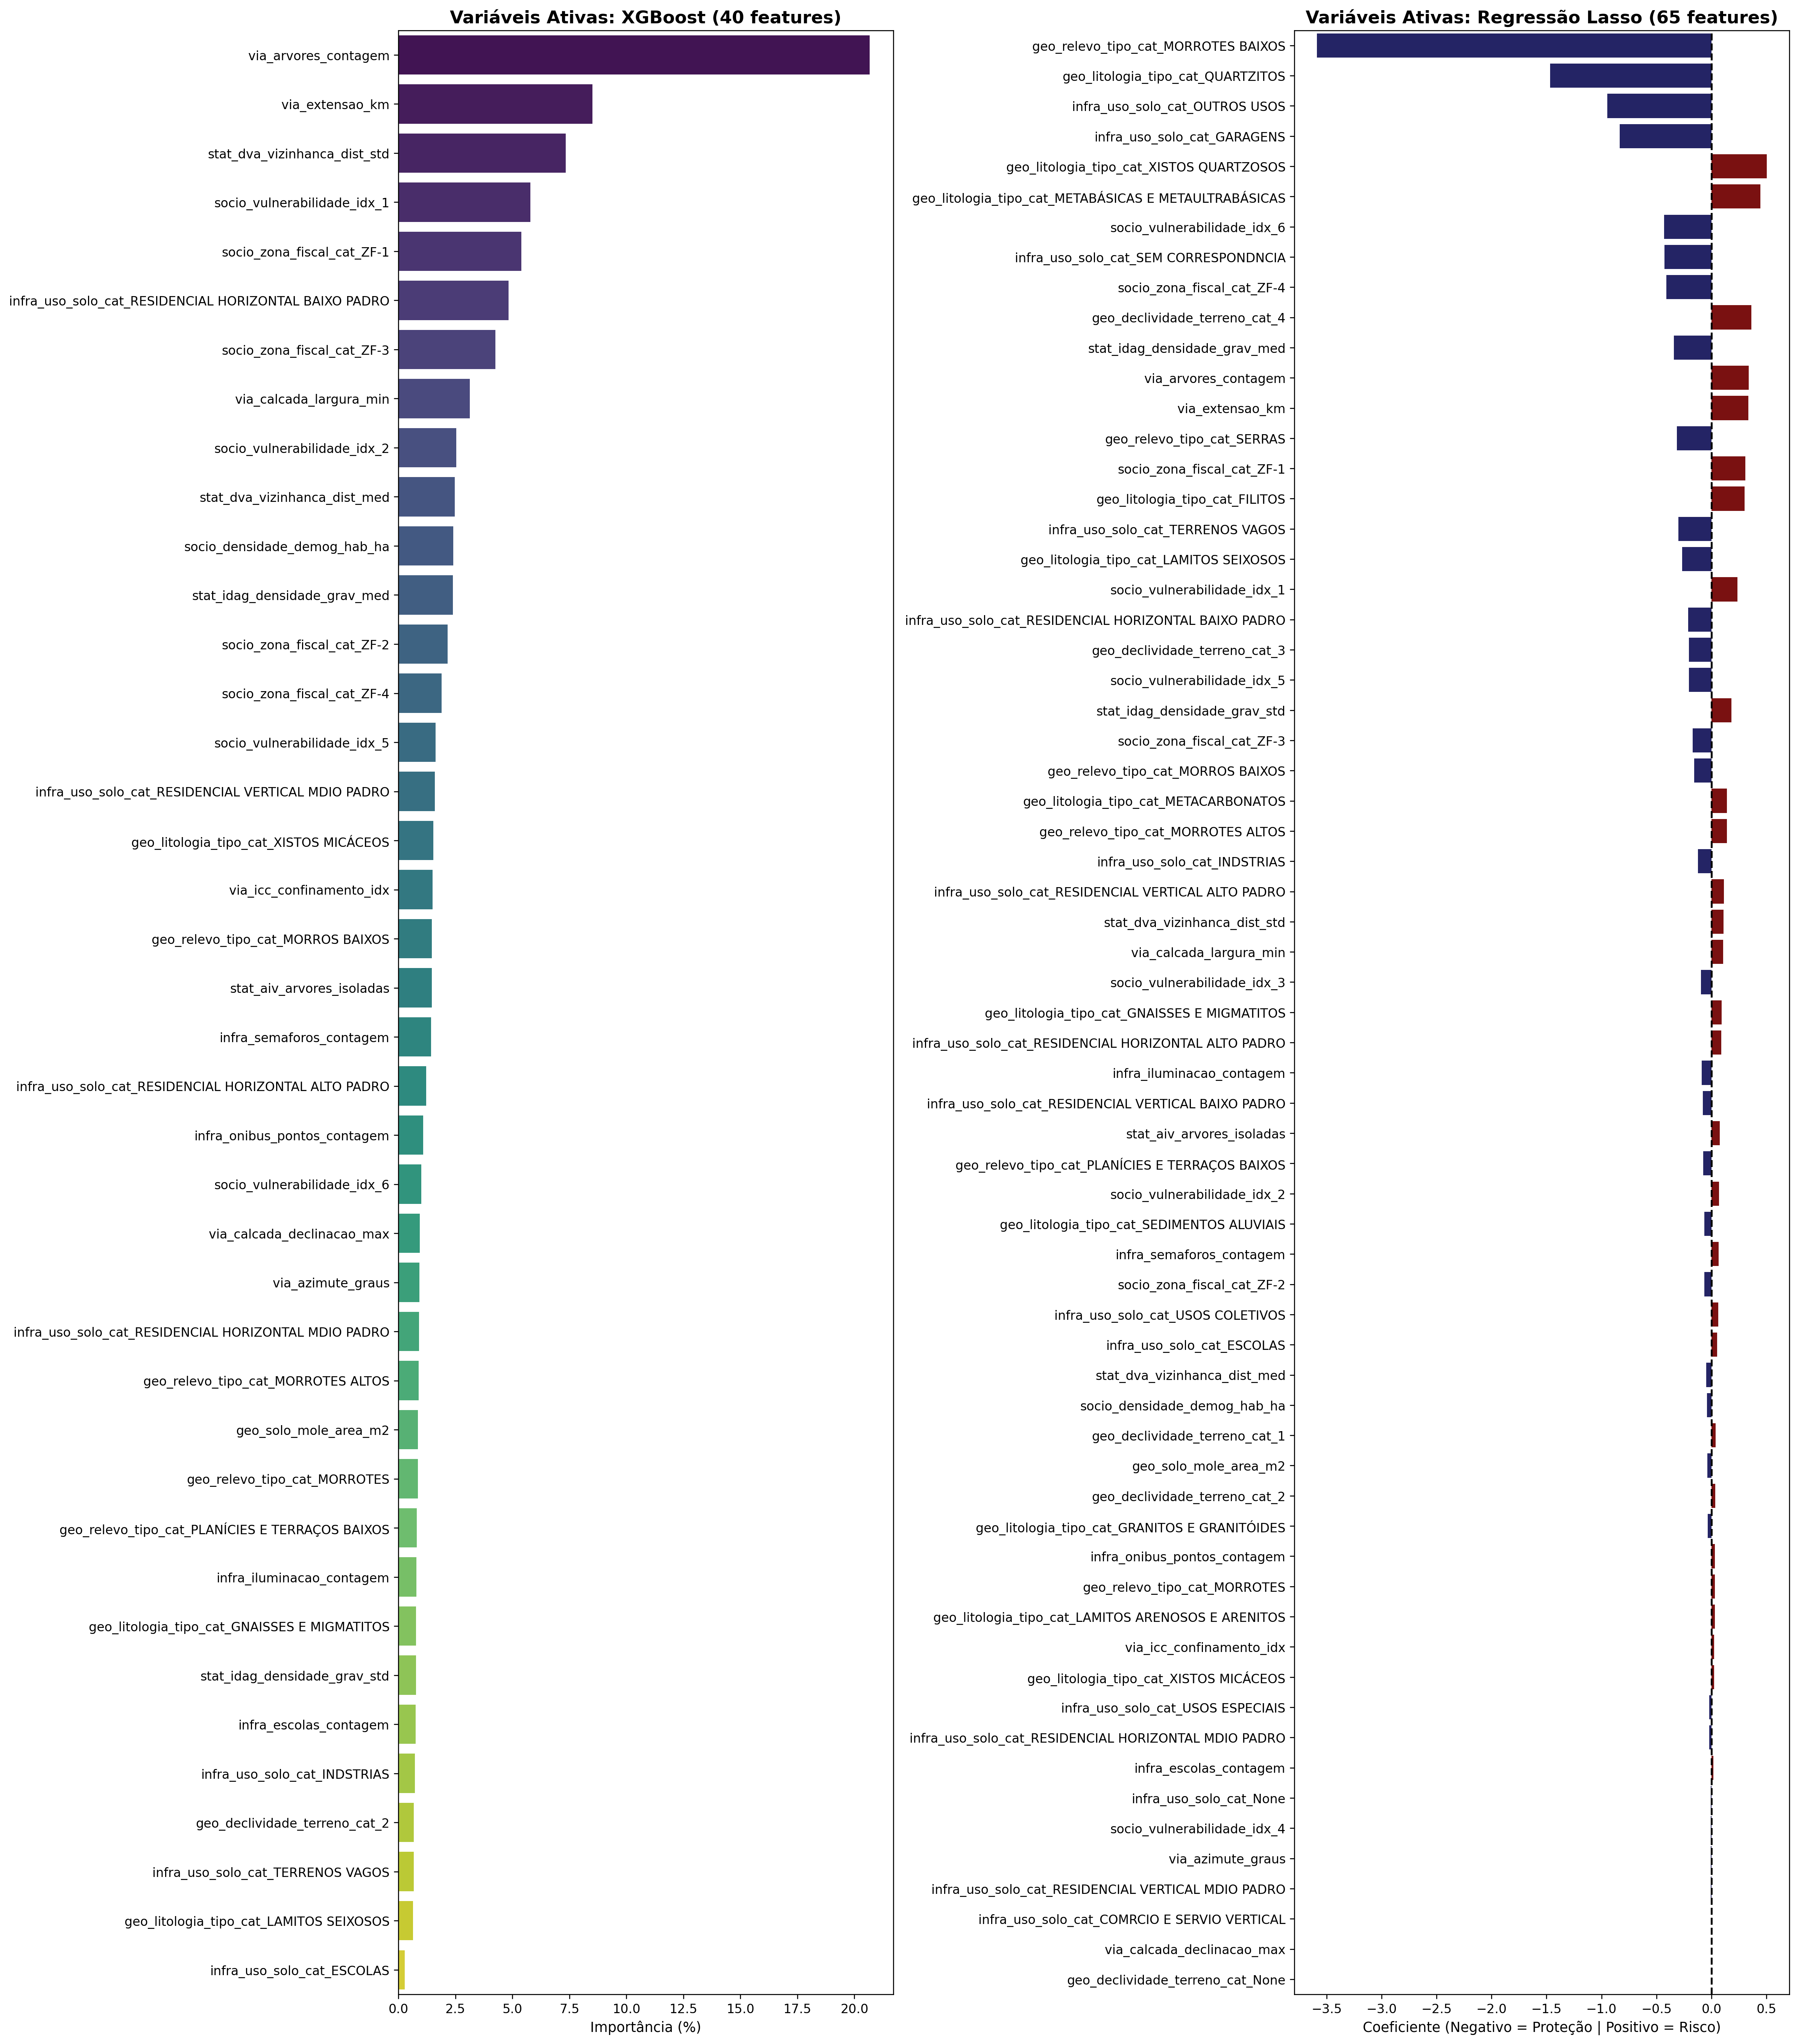

✅ Gráficos exportados com sucesso para: results/figures/05_importancia_exaustiva_modelos__20260331-1023_cenario_completo_triade_v1.png

🔍 RESUMO DA REGRESSÃO LASSO (Penalidade L1):
 - Sobreviveram: 65 variáveis.
 - Foram ZERADAS (descartadas por redundância ou irrelevância): 3 variáveis.

🗑️ Variáveis descartadas pelo Lasso:
infra_uso_solo_cat_COMRCIO E SERVIO HORIZONTAL | geo_relevo_tipo_cat_MORROS ALTOS | geo_relevo_tipo_cat_TERRAÇOS ALTOS

📈 FATORES DE RISCO (Coeficientes Positivos - Aumentam a chance de queda):
  + geo_litologia_tipo_cat_XISTOS QUARTZOSOS | Peso: 0.5019
  + geo_litologia_tipo_cat_METABÁSICAS E METAULTRABÁSICAS | Peso: 0.4445
  + geo_declividade_terreno_cat_4  | Peso: 0.3642
  + via_arvores_contagem           | Peso: 0.3388
  + via_extensao_km                | Peso: 0.3370
  + socio_zona_fiscal_cat_ZF-1     | Peso: 0.3091
  + geo_litologia_tipo_cat_FILITOS | Peso: 0.3018
  + socio_vulnerabilidade_idx_1    | Peso: 0.2352
  + stat_idag_densidade_grav_std   | Peso: 0.1

In [ ]:
# ==============================================================================
# CÉLULA 10: INTERPRETABILIDADE EXAUSTIVA (LASSO E XGBOOST LADO A LADO)
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("📊 Extraindo a importância de todas as variáveis dos modelos...")

# 1. Extração dos Dados Brutos (Usando os nomes atualizados dos pipelines)
coeficientes_lasso = pipe_lasso.named_steps['modelo'].coef_[0]
importancias_xgb = pipe_xgb_final.named_steps['modelo'].feature_importances_ * 100

feature_names = pipe_lasso.named_steps['pre'].get_feature_names_out()
feature_names_clean = [nome.replace('num__', '').replace('cat__', '') for nome in feature_names]

# 2. Consolidando no DataFrame Principal
df_importancia = pd.DataFrame({
    'Feature': feature_names_clean,
    'XGBoost (Força %)': importancias_xgb,
    'Lasso (Coeficiente)': coeficientes_lasso
})

# 3. Filtragem Independente para cada Modelo
# XGBoost: Apenas variáveis que contribuíram com algum ganho de informação (> 0)
df_xgb_plot = df_importancia[df_importancia['XGBoost (Força %)'] > 0].sort_values(by='XGBoost (Força %)', ascending=False)

# Lasso: Apenas variáveis que sobreviveram à penalidade L1 (!= 0)
df_lasso_plot = df_importancia[df_importancia['Lasso (Coeficiente)'] != 0].copy()
df_lasso_plot['Abs_Lasso'] = df_lasso_plot['Lasso (Coeficiente)'].abs()
df_lasso_plot = df_lasso_plot.sort_values(by='Abs_Lasso', ascending=False)

# Lasso: Variáveis Zeradas (Descartadas)
df_lasso_zeradas = df_importancia[df_importancia['Lasso (Coeficiente)'] == 0][['Feature']].copy()

# 4. Salvando as tabelas completas para o relatório (Padrão PT-BR)
caminho_tabela_xgb = f'results/tables/11a_importancia_xgboost_{sufixo_data}.csv'
caminho_tabela_lasso = f'results/tables/11b_importancia_lasso_{sufixo_data}.csv'

df_xgb_plot.to_csv(caminho_tabela_xgb, index=False, sep=';', decimal=',')
df_lasso_plot.drop(columns=['Abs_Lasso']).to_csv(caminho_tabela_lasso, index=False, sep=';', decimal=',')

# ==========================================
# 5. PLOTANDO OS GRÁFICOS DINÂMICOS
# ==========================================
# Calcula a altura ideal do gráfico baseado no modelo que tem mais variáveis ativas
max_vars = max(len(df_xgb_plot), len(df_lasso_plot))
altura_ideal = max(8, max_vars * 0.35)

fig, axes = plt.subplots(1, 2, figsize=(20, altura_ideal), dpi=120)

# Gráfico 1: XGBoost (Força Absoluta)
sns.barplot(x='XGBoost (Força %)', y='Feature', data=df_xgb_plot, ax=axes[0], palette='viridis')
axes[0].set_title(f'Variáveis Ativas: XGBoost ({len(df_xgb_plot)} features)', fontsize=14, weight='bold')
axes[0].set_xlabel('Importância (%)')
axes[0].set_ylabel('')

# Gráfico 2: Lasso (Direcionalidade)
cores_lasso = ['#8B0000' if val > 0 else '#191970' for val in df_lasso_plot['Lasso (Coeficiente)']]
sns.barplot(x='Lasso (Coeficiente)', y='Feature', data=df_lasso_plot, ax=axes[1], palette=cores_lasso)
axes[1].set_title(f'Variáveis Ativas: Regressão Lasso ({len(df_lasso_plot)} features)', fontsize=14, weight='bold')
axes[1].set_xlabel('Coeficiente (Negativo = Proteção | Positivo = Risco)')
axes[1].set_ylabel('')
axes[1].axvline(0, color='black', linewidth=1.5, linestyle='--') # Linha central destacada

plt.tight_layout()
caminho_figura = f'results/figures/05_importancia_exaustiva_modelos_{sufixo_data}.png'
plt.savefig(caminho_figura, dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 6. RELATÓRIO DE DESCARTE (LASSO)
# ==========================================
print(f"✅ Gráficos exportados com sucesso para: {caminho_figura}")
print(f"\n🔍 RESUMO DA REGRESSÃO LASSO (Penalidade L1):")
print(f" - Sobreviveram: {len(df_lasso_plot)} variáveis.")
print(f" - Foram ZERADAS (descartadas por redundância ou irrelevância): {len(df_lasso_zeradas)} variáveis.")

if len(df_lasso_zeradas) > 0:
    print("\n🗑️ Variáveis descartadas pelo Lasso:")
    lista_zeradas = df_lasso_zeradas['Feature'].tolist()
    for i in range(0, len(lista_zeradas), 3):
        print(" | ".join(lista_zeradas[i:i+3]))

# ==============================================================================
# 7. RELATÓRIO DETALHADO: FATORES DE RISCO E PROTEÇÃO (LASSO)
# ==============================================================================
print("\n📈 FATORES DE RISCO (Coeficientes Positivos - Aumentam a chance de queda):")
risco_lasso = df_lasso_plot[df_lasso_plot['Lasso (Coeficiente)'] > 0].sort_values(by='Lasso (Coeficiente)', ascending=False)

if not risco_lasso.empty:
    for _, row in risco_lasso.iterrows():
        print(f"  + {row['Feature']:<30} | Peso: {row['Lasso (Coeficiente)']:.4f}")
else:
    print("  Nenhum fator de risco retido pelo modelo.")

print("\n🛡️ FATORES DE PROTEÇÃO (Coeficientes Negativos - Reduzem a chance de queda):")
protecao_lasso = df_lasso_plot[df_lasso_plot['Lasso (Coeficiente)'] < 0].sort_values(by='Lasso (Coeficiente)', ascending=True)

if not protecao_lasso.empty:
    for _, row in protecao_lasso.iterrows():
        print(f"  - {row['Feature']:<30} | Peso: {row['Lasso (Coeficiente)']:.4f}")
else:
    print("  Nenhum fator de proteção retido pelo modelo.")

In [ ]:
# ==============================================================================
# CÉLULA EXTRAS: SALVAMENTO FÍSICO DO MODELO E THRESHOLD
# ==============================================================================
import joblib
import os

print("💾 Salvando o modelo XGBoost final e o Threshold Operacional...")

# Garante que a pasta existe
os.makedirs('results/models', exist_ok=True)

# Define os caminhos de salvamento baseados no nome do seu cenário
caminho_modelo = f'results/models/modelo_xgb_{nome_cenario}.pkl'
caminho_threshold = f'results/models/threshold_{nome_cenario}.pkl'

# Exporta os objetos
joblib.dump(pipe_xgb_final, caminho_modelo)
joblib.dump(threshold_otimo, caminho_threshold)

print(f"✅ Modelo salvo em: {caminho_modelo}")
print(f"✅ Threshold ({threshold_otimo:.2f}) salvo em: {caminho_threshold}")
print("🚀 Agora você pode abrir o Notebook 03_mapa com segurança!")

💾 Salvando o modelo XGBoost final e o Threshold Operacional...
✅ Modelo salvo em: results/models/modelo_xgb_cenario_completo_triade_v1.pkl
✅ Threshold (0.46) salvo em: results/models/threshold_cenario_completo_triade_v1.pkl
🚀 Agora você pode abrir o Notebook 03_mapa com segurança!
